# Credit Scoring Prediction — Give Me Some Credit

**Autor:** Brandon Uriel García Sánchez — Científico de Datos para Negocios · Finanzas / IA

**Dataset / Competencia:** [Kaggle - Give Me Some Credit](https://www.kaggle.com/competitions/GiveMeSomeCredit)

## Por qué hago este proyecto

Este es un proyecto personal, parte de mi portafolio como científico de datos. Elegí *credit scoring* porque es uno de los casos de uso más clásicos y relevantes de machine learning aplicado a finanzas: no es un problema sencillo, es el tipo de modelo que un banco real usa todos los días para decidir si te presta dinero o no. Me interesa trabajarlo por tres razones:

- Practicar un pipeline completo de ciencia de datos de punta a punta (limpieza, EDA, feature engineering, modelado y evaluación) sobre un dataset real y desbalanceado.
- Mostrar que puedo tomar un problema de negocio (¿a quién le presto?) y traducirlo en un problema de predicción con métricas claras (probabilidad de default).
- Profundizar en el manejo de datos con valores faltantes y outliers reales, algo muy común en datasets financieros y poco común en datasets de práctica ya limpios.

## Descripción del problema

Los bancos cumplen un rol fundamental en las economías de mercado: deciden quién puede acceder a financiamiento y en qué condiciones, lo que puede definir el éxito o fracaso de decisiones de inversión tanto para personas como para empresas. Para que el crédito se otorgue de forma responsable, los bancos necesitan estimar con anticipación qué tan probable es que un solicitante no pague.

Los algoritmos de *credit scoring* hacen justo eso: estiman la probabilidad de que un solicitante caiga en incumplimiento de pago (default), y son el método que utilizan los bancos para decidir si otorgar o no un préstamo. El objetivo de este proyecto es predecir la probabilidad de que una persona experimente dificultades financieras graves (90+ días de atraso) en los próximos dos años.

## Diccionario de variables

| Variable | Descripción | Tipo |
|---|---|---|
| **SeriousDlqin2yrs** | Variable objetivo (target). Indica si la persona experimentó una ausencia de pago de 90 días o más (1 = sí, 0 = no). | Binaria (0/1) |
| **RevolvingUtilizationOfUnsecuredLines** | Saldo total en tarjetas de crédito y líneas de crédito personales (sin garantía), excluyendo deudas inmobiliarias y préstamos a plazo tipo automotor, dividido por la suma de los límites de crédito disponibles. | Ratio  |
| **age** | Edad del solicitante en años. | Entero |
| **NumberOfTime30-59DaysPastDueNotWorse** | Cantidad de veces que el solicitante se atrasó entre 30 y 59 días en un pago, sin llegar a un atraso peor, en los últimos 2 años. | Entero |
| **DebtRatio** | Pagos mensuales de deuda, alimentos/pensiones y gastos de vida, divididos por el ingreso bruto mensual. | Ratio |
| **MonthlyIncome** | Ingreso mensual. | Continua |
| **NumberOfOpenCreditLinesAndLoans** | Cantidad de préstamos abiertos (como créditos automotores o hipotecas) y líneas de crédito (como tarjetas de crédito). | Entero |
| **NumberOfTimes90DaysLate** | Cantidad de veces que el solicitante se atrasó 90 días o más en un pago. | Entero |
| **NumberRealEstateLoansOrLines** | Cantidad de préstamos hipotecarios y de bienes raíces, incluyendo líneas de crédito con garantía hipotecaria (home equity). | Entero |
| **NumberOfTime60-89DaysPastDueNotWorse** | Cantidad de veces que el solicitante se atrasó entre 60 y 89 días en un pago, sin llegar a un atraso peor, en los últimos 2 años. | Entero |
| **NumberOfDependents** | Cantidad de dependientes en la familia, sin contar al propio solicitante (cónyuge, hijos, etc.). | Entero |

**Retos esperados:** el target está desbalanceado (la mayoría de los solicitantes no cae en default), así que *accuracy* no es una métrica confiable aquí — se usará AUC-ROC y precision/recall. Además, `MonthlyIncome` tiene ~20% de valores faltantes, y tanto `DebtRatio` como `RevolvingUtilizationOfUnsecuredLines` presentan outliers extremos que sugieren errores de captura o casos borde. Ninguno de los dos problemas se va a resolver rellenando a ciegas: ambos se investigan y se documentan en la sección de limpieza.

## Archivos del dataset

- `cs-training.csv` — set de entrenamiento, incluye la variable objetivo `SeriousDlqin2yrs`.
- `cs-test.csv` — set de prueba, sin la variable objetivo (a predecir).
- `sampleEntry.csv` — formato de ejemplo para la entrega de predicciones (`Id`, `Probability`).
- `Data Dictionary.xls` — diccionario de variables original.

In [1]:
import pandas as pd # importamos pandas para el manejo de datos
import matplotlib.pyplot as plt # crear gráficos
import seaborn as sns # damos diseño 
import numpy as np # manejar arrays
from sklearn.model_selection import train_test_split # separar el dataset
from sklearn.impute import SimpleImputer # usamos una estrategia de mediana en outliers
from sklearn.preprocessing import StandardScaler # Escalamos las varialbes 0 - 1
from sklearn.linear_model import LogisticRegression # Machine learning clasificatorio, regresion logistica
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve # metricas de evaluación
import shap # explicabilidad del modelo

In [2]:
df = pd.read_csv(r"C:\Users\Uriel\Desktop\Ciencias de datos  IA  proyectos\Credit Scoring Predicting\cs-training.csv") # Creamos un dataframe leyendo el contenido de nuestro csv
# df = pd.read_csv("cs-training.csv")
df.head(20) # leemos el dataframe

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


## Análisis Exploratorio de Datos (EDA)

Antes de limpiar o modelar cualquier cosa, primero hay que entender qué hay realmente en los datos: su estructura, calidad, valores faltantes, outliers y relación con el target. Esta sección documenta ese proceso paso a paso.

In [3]:
df.info() # obtenemos la información de los datos y tipó de variables

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [4]:
df.describe() # obtenemos un analisis estadistico de cada una de nuestras variables

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Observaciones sobre `DebtRatio` y `MonthlyIncome`
Valores atípicos en DebtRatio: se esperaría que esta columna tome valores razonables (ratios del orden de 1, 2 o 3), sin embargo se observan registros con valores superiores a 100, lo cual no tiene sentido en términos del significado de la variable (un ratio de deuda sobre ingreso no debería dispararse tanto).

Coincidencia con nulos en MonthlyIncome: al revisar esos mismos registros con DebtRatio anómalo, se nota que justamente corresponden a filas donde MonthlyIncome es NaN (valor nulo). Esto sugiere que el ratio se está calculando mal (o queda inflado) precisamente cuando falta el ingreso mensual, lo que explicaría los valores extremos.

In [5]:
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


Justamente vemos nuestra metrica principal con un 93.316% que sí pagarón y el 6.68% no pagaron en un lapso de 2 años tardaron >90 días en pagar, esto tiene un problema porque a la hora de entrenar nuestro modelo no podemos fiarnos de nuestra métrica "accuracy" lo cual optaremos a evaluar a futuro nuestra metrica con AUC

In [6]:
print(df[['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']].max()) # Vemos numeros maximos de las 3 columnas de días


NumberOfTime30-59DaysPastDueNotWorse    98
NumberOfTime60-89DaysPastDueNotWorse    98
NumberOfTimes90DaysLate                 98
dtype: int64


Reviso estas tres columnas porque en el describe() anterior vi que su percentil 75% estaba en 0, pero el máximo se disparaba mucho más arriba — la misma señal que ya había visto en DebtRatio y RevolvingUtilization.

In [7]:
print(df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index(ascending=False).head(10)) 


NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
10      4
9      12
8      25
7      54
6     140
Name: count, dtype: int64


El máximo es 98, y aparece en 264 filas (96 en 5 filas más). Esto no puede ser un conteo real de atrasos — es un código especial que probablemente marca algo como "sin historial" o "cuenta cerrada", no lo voy a tratar como un número normal.

In [8]:
print((df['MonthlyIncome'] > 100000).sum())
print(df['NumberOfDependents'].value_counts().sort_index(ascending=False).head(10))
print((df['DebtRatio'] > 10).sum())
print((df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum())
print(df[df['DebtRatio'] > 10]['MonthlyIncome'].isna().mean())

70
NumberOfDependents
20.0       1
13.0       1
10.0       5
9.0        5
8.0       24
7.0       51
6.0      158
5.0      746
4.0     2862
3.0     9483
Name: count, dtype: int64
28877
371
0.9270699864944419


De estos resultados: 70 personas ganan más de 100,000 al mes (raro pero real, no error). Los dependientes van bajando poco a poco hasta 20 (distribución natural, no error). Pero lo importante es DebtRatio: 28,877 filas (19.25%) tienen un valor mayor a 10, y de esas, el 92.7% tiene MonthlyIncome faltante. No es un error aislado, es un patrón sistemático: el ratio se dispara justo cuando falta el ingreso.

In [9]:
print((df['age'] == 0).sum())


1


Solo 1 fila tiene age = 0, imposible para alguien pidiendo un crédito. Es un error de captura aislado, no un patrón.

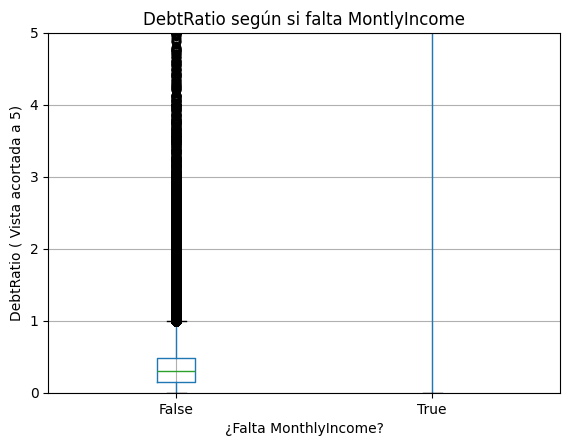

In [10]:
df['income_missing'] = df['MonthlyIncome'].isna()

df.boxplot(column='DebtRatio', by='income_missing')
plt.ylim(0,5)
plt.title('DebtRatio según si falta MontlyIncome')
plt.suptitle('')
plt.xlabel('¿Falta MonthlyIncome?')
plt.ylabel('DebtRatio ( Vista acortada a 5)')
plt.show()

La caja de "True" (falta el ingreso) no se ve en el gráfico no es un error, significa que sus valores de DebtRatio son tan altos que ni caben en el rango que dibujé (0 a 5). Confirma con evidencia visual lo que ya habíamos visto con los números.

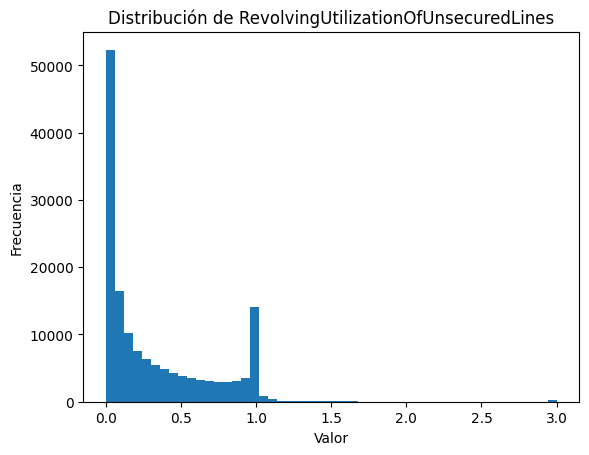

In [11]:
plt.hist(df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=3),bins=50)
plt.title('Distribución de RevolvingUtilizationOfUnsecuredLines')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()


Hay un pico raro justo en 1.0 que no encaja con la caída suave del resto.

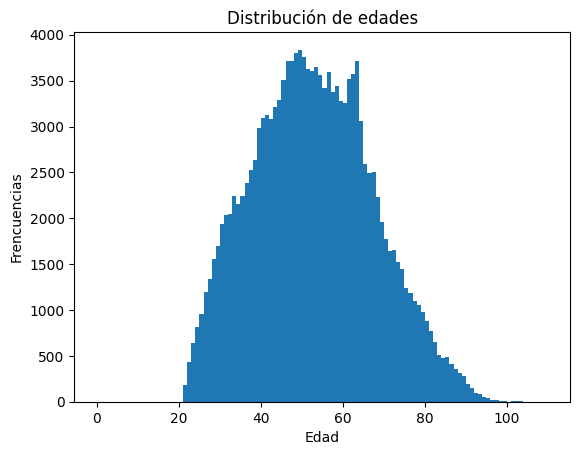

In [12]:
plt.hist(df['age'], bins=range(int(df['age'].min()), int(df['age'].max()) + 2))
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frencuencias')
plt.show()

Se ven dos picos que resaltan cerca de 48-50 y 60. Podría ser "age heaping" (gente redondeando su edad) o solo un artefacto del histograma

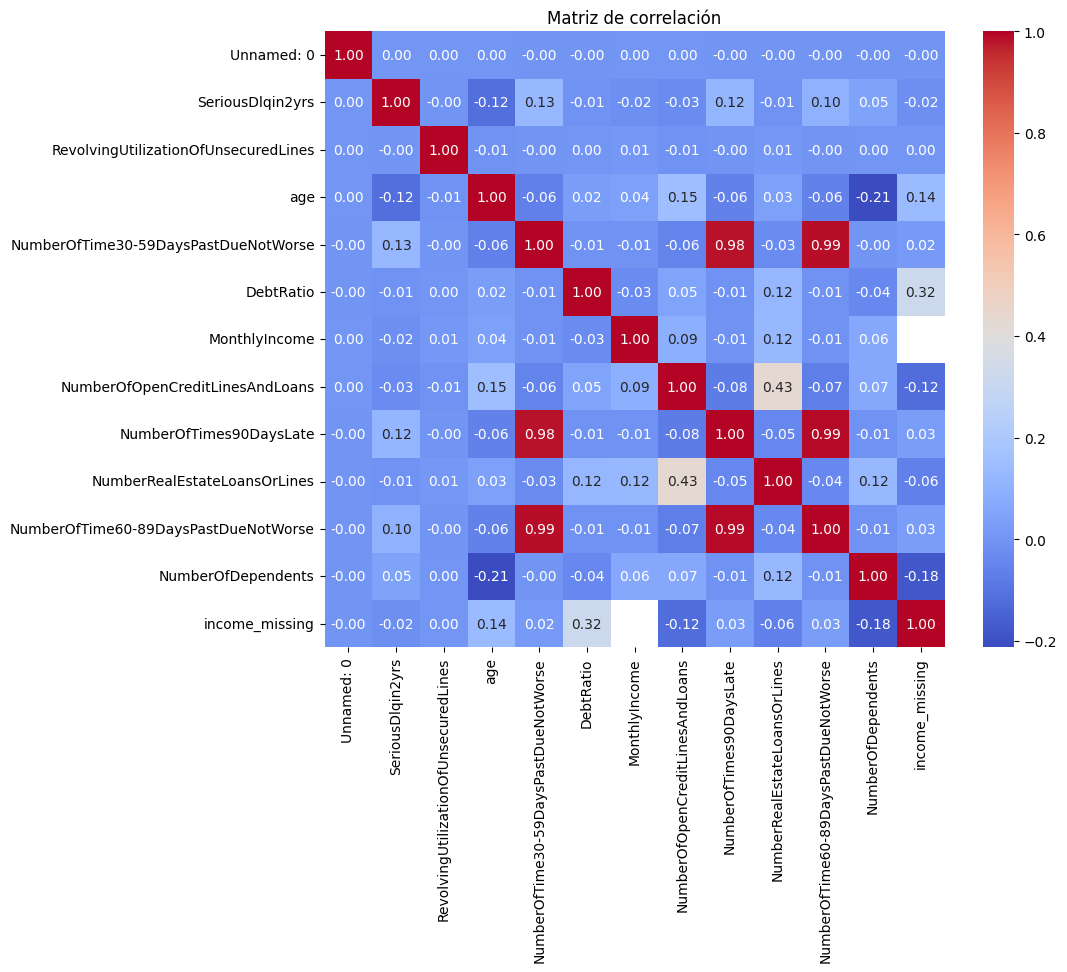

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Las tres columnas de días de atraso están casi perfectamente correlacionadas entre sí (0.98-0.99), confirma que comparten el mismo origen. Pero DebtRatio y RevolvingUtilization casi no se correlacionan con el target (-0.01 y -0.00) — raro, porque en teoría deberían importar para el riesgo de default.

In [14]:
print(df[['DebtRatio','RevolvingUtilizationOfUnsecuredLines','SeriousDlqin2yrs']].corr(method='spearman'))


                                      DebtRatio  \
DebtRatio                              1.000000   
RevolvingUtilizationOfUnsecuredLines   0.076564   
SeriousDlqin2yrs                       0.020597   

                                      RevolvingUtilizationOfUnsecuredLines  \
DebtRatio                                                         0.076564   
RevolvingUtilizationOfUnsecuredLines                              1.000000   
SeriousDlqin2yrs                                                  0.240378   

                                      SeriousDlqin2yrs  
DebtRatio                                     0.020597  
RevolvingUtilizationOfUnsecuredLines          0.240378  
SeriousDlqin2yrs                              1.000000  


Con Spearman, RevolvingUtilization pasa de -0.00 a 0.24 — confirma que los outliers estaban tapando una relación real. DebtRatio se queda en 0.02, casi sin cambio: ahí no hay señal escondida, la variable está mayormente corrupta por el problema del ingreso faltante.

In [15]:
print((df['RevolvingUtilizationOfUnsecuredLines'] == 1.0).sum())
print(df['age'].value_counts().sort_index().loc[45:65])

17
age
45    3502
46    3714
47    3719
48    3806
49    3837
50    3753
51    3627
52    3609
53    3648
54    3561
55    3416
56    3589
57    3375
58    3443
59    3280
60    3258
61    3522
62    3568
63    3719
64    3058
65    2594
Name: count, dtype: int64


Solo 17 filas tienen RevolvingUtilization exactamente en 1.0  no es un código especial, es gente real cerca de su límite de crédito. Y en las edades 45-65 los conteos son parejos (sin ningún salto en 50 o 60): no hay age heaping real, la distribución de edad está limpia.

## Diagnóstico de calidad de datos (EDA)

Encontré estos problemas antes de entrenar el modelo:

1. **Target desbalanceado:** 93.32% no cayó en default, 6.68% sí. Por esto descarto accuracy y uso ROC-AUC.
2. **`MonthlyIncome`:** ~20% de datos faltantes.
3. **`DebtRatio`:** ~19.25% de las filas (28,877) tienen valores mayores a 10 (hasta 329,664). El 92.7% de esas filas coincide con `MonthlyIncome` faltante — patrón sistemático ligado al ingreso, se resuelve junto con su imputación. Confirmé con Spearman que no hay relación real escondida con el target (0.02): esta variable está mayormente corrupta, no aporta señal en su estado actual.
4. **`RevolvingUtilizationOfUnsecuredLines`:** solo 371 filas (0.25%) superan un valor de 2 — outlier aislado real, se trata con un cap. El pico visual cerca de 1.0 no es un código especial (solo 17 filas valen exactamente 1.0): es gente real cerca de su límite de crédito. Con Spearman esta variable sí tiene relación real con el target (0.24) — los outliers tapaban la señal con Pearson (-0.00). Es una variable importante para el modelo.
5. **Columnas de días de atraso:** las tres comparten el mismo valor máximo (98 en 264 filas, 96 en 5 filas) — no son conteos reales, es un código especial. Además están casi perfectamente correlacionadas entre sí (0.98-0.99), señal de que comparten el mismo origen — se tratarán con cuidado en el modelado por posible redundancia.
6. **`age = 0` en 1 fila:** error de captura aislado. Revisé edades 45-65 una por una — no hay heaping real en 50 o 60 (conteos parejos, 2,500-3,800), la distribución de edad está limpia.

Con esto ya sé qué arreglar antes de modelar, cuáles problemas están conectados entre sí, y qué variables tienen señal real.

## Preprocesamiento de datos y Feature Engineering
Con el diagnóstico del EDA ya claro, esta sección corrige los problemas de calidad de datos encontrados
(age = 0, códigos centinela, valores faltantes y outliers) y prepara las variables para el modelo. Los pasos que no dependen de ningún número calculado de los datos van antes del train / test split; los que si dependen de una estadística (mediana, percentiles) van después, calculados solo con el set de entrenamiento para evitar fuga de datos.

In [16]:
# Eliminamos la única fila con age = 0: es un error de captura, no un dato real posible
# No depende de ningún número calculado de los datos, asi que puede hacer antes del split.
df = df[df['age']!=0]
print(df.shape)

(149999, 13)


Quité la única fila de con 'age = 0' - el cual era error de captura. El dataset pasa de 150,000 a 149,999 filas y 13 columnas

In [17]:
cols_atraso = ['NumberOfTime30-59DaysPastDueNotWorse',
               'NumberOfTime60-89DaysPastDueNotWorse',
               'NumberOfTimes90DaysLate']

# Guardamos si la fila tenía código especial entre (96 o 98) antes de perder la información
# No la borramos al completo: puede que el hecho de tener ese código en sí diga algo del cliente.
df['tiene_codigo_especial'] = df[cols_atraso].isin([96,98]).any(axis=1)

# Reemplazamos 96 y 98 por NaN - ya no son conteos reales, se imputarán después del split.
for col in cols_atraso:
  df[col] = df[col].replace([96,98], np.nan)
print(df['tiene_codigo_especial'].sum())
print(df[cols_atraso].isna().sum())

269
NumberOfTime30-59DaysPastDueNotWorse    269
NumberOfTime60-89DaysPastDueNotWorse    269
NumberOfTimes90DaysLate                 269
dtype: int64


En vez de borrar los 269 registros con código espcial (96 y 98), creé una bandera `tiene_codigo_especial`
para no perder esa información, y reemplacé el valor original por NaN - ya no representa un conteo real,
se imputará junto con el resto de los faltantes después del split.

In [18]:
# Separamos features (X) del target (y). Quitamos 'SeriousDlqin2yrs' porque es lo que queremos predecir,
# y 'Unnamed: 0' porque es solo el índice que quedó pegado al exportar el CSV, no es una variable real

X= df.drop(columns=['SeriousDlqin2yrs','Unnamed: 0'])
y = df['SeriousDlqin2yrs']

# Partimos en 80% train / 20% test. Usamos stratify = y porque el target esta desbalanceado (6.68% default):
# sin stratify, la particion aleatoria podría dejar proporciones distintas de default en train y test por azar.
# random_state=42 fija la semilla para que el split sea reproducible (mismo resultado cada vez que se corra)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)
# verific campos tamaños y que la proporcion de default se mantienga igual en ambos sets

print(X_train.shape, X_test.shape)
print(y_train.mean(),y_test.mean())

(119999, 12) (30000, 12)
0.06684222368519738 0.06683333333333333


### Imputación de `MonthlyIncome`
`MonthlyIncome` tiene ~20% de valores faltantes. Vamos a rellenarlos con la mediana (más robusta que la
media cuando hay outliers, y ya vimos que esta variable los tiene). La mediana se calcula **solo con `X_train`** y se aplica igual a `X_train` y `X_test` - asi no se filtra información del set de prueba hacia el entrenamiento (data leakage)

*Nota* Si usamos las media inflarían los datos hacia arriba por datos extremos de 3 millones en valor y una mediana hace que sea más equilibrado. 

In [19]:
# Creamos el imputador con estrategía de colocarle medianas ( robusta a outliers, mejor que una media en este caso)
imputer = SimpleImputer(strategy="median")

# fit_transform en train: aprende la mediana y la aplica, ambos usando solo datos de entrenamiento
X_train['MonthlyIncome'] = imputer.fit_transform(X_train[["MonthlyIncome"]])

# transform (sin fit) en test: aplica la MISMA mediana ya aprendida de train no calcula una nueva
X_test['MonthlyIncome'] = imputer.transform(X_test[['MonthlyIncome']])

print(X_train['MonthlyIncome'].isna().sum(), X_test['MonthlyIncome'].isna().sum())


0 0


In [20]:
# Imputador propio para NumberOfDependents (mediana, calculada solo con train)
imputer_dependents = SimpleImputer(strategy='median')

X_train['NumberOfDependents'] = imputer_dependents.fit_transform(X_train[['NumberOfDependents']])
X_test['NumberOfDependents'] = imputer_dependents.transform(X_test[['NumberOfDependents']])

print(X_train['NumberOfDependents'].isna().sum(), X_test['NumberOfDependents'].isna().sum())

0 0


# Realizamos lo mismo con los demás columnas con NaN 

In [21]:
imputer_atrasos = SimpleImputer(strategy='median')
X_train[cols_atraso] = imputer_atrasos.fit_transform(X_train[cols_atraso])
X_test[cols_atraso] = imputer_atrasos.transform(X_test[cols_atraso])

print(X_train[cols_atraso].isna().sum())
print(X_test[cols_atraso].isna().sum())

NumberOfTime30-59DaysPastDueNotWorse    0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTimes90DaysLate                 0
dtype: int64
NumberOfTime30-59DaysPastDueNotWorse    0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfTimes90DaysLate                 0
dtype: int64


### Capado de outliers en DebtRatio y RevolvingUtilizationOfUnsecuredLines

Ambas variables tienen valores extremos que rompen su rango teórico (0-2 o 3 aprox.). En vez de borrar esas.
filas (perderíamos información, y en RevolvingUtilization ya sabes que sí hay señal real) **Confirmados en el EDA**, las vamos a " capar": cualquier valor por encima del percentil 99 se reemplaza por el valor del percentil 99. El percentil se calcula solo con train, igual con la mediana para no filtrar información del test set.


In [22]:
# Calculamos el percentil 99 SOLO con train (no con todo el dataset)
cap_debtratio = X_train['DebtRatio'].quantile(0.99)
cap_revolving = X_train['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)

# Aplicamos el mismo límite (aprendido de train) a train y test
X_train['DebtRatio'] = X_train['DebtRatio'].clip(upper=cap_debtratio)
X_test['DebtRatio'] = X_test['DebtRatio'].clip(upper=cap_debtratio)

X_train['RevolvingUtilizationOfUnsecuredLines'] = X_train['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap_revolving)
X_test['RevolvingUtilizationOfUnsecuredLines'] = X_test['RevolvingUtilizationOfUnsecuredLines'].clip(upper=cap_revolving)

print(cap_debtratio, cap_revolving)
print(X_train['DebtRatio'].max(), X_train['RevolvingUtilizationOfUnsecuredLines'].max())

4983.040000000008 1.0959067669800004
4983.040000000008 1.0959067669800004


Aqui identifiqué un problema el DebtRatio esta en 4983.04 siendo un número muy alto en el contexto del dataset, lo cual tiene fundamento por que el ~19% del dataset esta corrompido, aqui usaremos un limite fijo basado en el significado del libro de variables

In [23]:
cap_debtratio_fijo = 3 # colocamos el prefijo
X_train['DebtRatio'] = X_train['DebtRatio'].clip(upper=cap_debtratio_fijo) # los reemplazamos a train y test
X_test['DebtRatio'] = X_test['DebtRatio'].clip(upper=cap_debtratio_fijo)

print(X_train['DebtRatio'].max(), X_test['DebtRatio'].max()) # vemos los maximos de ambos

3.0 3.0


Por ultimo haremos un resúmen general de todos nuestros datos

In [24]:
print(X_train.isna().sum().sum(), X_test.isna().sum().sum())
X_train.describe()

0 0


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,119999.000000,119999.000000,119999.000000,119999.000000,1.199990e+05,119999.000000,119999.000000,119999.000000,119999.000000,119999.000000
mean,0.320132,52.315044,0.245202,0.886448,6.410109e+03,8.463721,0.090017,1.019617,0.065184,0.736198
std,0.352162,14.758696,0.696959,1.105555,1.095169e+04,5.152946,0.482563,1.135512,0.330963,1.107638
min,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029663,41.000000,0.000000,0.175373,3.900000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.153211,52.000000,0.000000,0.366829,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.558129,63.000000,0.000000,0.864803,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.095907,109.000000,13.000000,3.000000,1.794060e+06,58.000000,17.000000,54.000000,11.000000,20.000000


Tenemos 0 - 0 en nulos, nuestros datos parecen estar limpios, estar completos y en un rango normal para pasar a ser entrenados por un modelo de machine learning

### Resumen del preprocesamiento

Al final de esta fase: sin valores faltantes en ninguna columna (`MonthlyIncome`, `NumberOfDependents` y las 
tres columnas de días de atraso imputadas con la mediana de train), sin códigos raros (269 
filas marcadas con `tiene_codigo_especial` antes de convertir 96/98 a NaN), y sin outliers absurdos 
(`RevolvingUtilization` topado en 1.10, `DebtRatio` topado en 3.0, ambos límites decididos con criterio y fundamentados anteriormente). El dataset queda listo para entrenar un modelo baseline.

## Modelado baseline y comparación

Empezamos con un modelo simple e interpretable (regresión logística) como punto de referencia y después lo comparamos contra un modelo más complejo como el random forest. La regresion lógistica necesita variables que estén en la misma escala para funcionar bien - así que este será el primer paso antes de entrenar

### Por qué regresión logística como baseline

Uso regresión logística como primer modelo porque, a diferencia de modelos más complejos, no es una "caja negra": 
en vez de predecir la probabilidad de default directamente con una línea recta (lo cual no tendría sentido, una 
probabilidad no puede ser negativa ni mayor a 1), modela el logaritmo de los momios (log-odds) como una combinación 
lineal de las variables, y usa la función sigmoide para convertir eso en una probabilidad entre 0 y 1.

Esto importa porque cada coeficiente del modelo es interpretable: dice cuánto cambia el riesgo de default por 
cada variable, sin necesitar técnicas adicionales para "explicar" al modelo por fuera. En un contexto bancario 
regulado, eso es tan importante como la precisión misma — un banco necesita poder justificar por qué le negó 
un crédito a alguien, no solo saber que el modelo "funciona".

Por esto también escalamos las variables antes de entrenar: los coeficientes solo son comparables entre sí 
si todas las variables están en la misma escala.

In [25]:
# Creamos el escalador (mismo patron que el imputer: un objeto que "aprende" algo de los datos)

scaler = StandardScaler()

# fit_transform en train: aprende la media y desviaciíon estándar de CADA columnas y las aplica
X_train_scaled = scaler.fit_transform(X_train)

# Transform (sin fit) en test: usa la MISMA media/desviación aprendida del train
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0).round(2))  # deberían salir todas cerca de 0
print(X_train_scaled.std(axis=0).round(2))   # deberían salir todas cerca de 1

[ 0.  0.  0.  0.  0.  0. -0.  0. -0.  0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
print(X_train.shape)
print(X_train.columns.tolist())

(119999, 12)
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'income_missing', 'tiene_codigo_especial']


In [27]:
# class_weight ='balanced' para compensar el desbalance del target (93% / 7%)
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Probabilidad de default (sin la case directa) - la usaremos para metricas en la siguiente fase
y_proba = log_reg.predict_proba(X_test_scaled)[:,1]
y_pred = log_reg.predict(X_test_scaled)

print("Modelo entrenado, output: {}")

Modelo entrenado, output: {}


### Entrenamiento del modelo baseline (Regresión Logistica)

Entrenamos una regresión logistica con `class_weight='balanced'` para compensar el desbalance del target
(93% no default / 7% default) - sin esto, el modelo tendería a ignorar la clase minoritaria. Usamos las
variables ya escaladas ('X_train_scaled'), porque los coeficientes de este modelo dependen de la magnitud
de cada variable. Guardamos tanto la clase predicha ('y_pred') como la probabilidad default ('y_proba'),
que es la que realmente nos interesa para las metricas de la siguiente fase.

In [28]:
rf = RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf = rf.predict(X_test)

print("Listo, Random Forest Entrenado")

Listo, Random Forest Entrenado


### Modelo de compración (Random Forest)
Entrenamos un Random Forest como segundo modelo, para comparar contra la regresión logística. A diferencia
de estar, no necesita variables escaladas entre 0 y 1 - los arboles de decisión parten los datos por umbrales, no les
importa la escala de cada variable. Tambien usamos `class_weight='balanced'` aquí, por la misma razón que 
en la regresión logística: compensar el desbalance del target.

## Evaluación con métricas correctas

Ya establecimos desde el EDA que accuracy no sirve aquí por el desbalance del target. Evaluamos ambos
modelos con AUC-ROC (qué tan bien separa el modelo a quienes sí caen en default de quienes no, sinn importar
el umbral de decisión) y con precisión/recall (qué tan confiables son las predicciones positivas y que tan
bien capturamos a los que sí caen en default).

In [29]:
print("==== Regresión Logística ====")
print("AUC-ROC:", roc_auc_score(y_test,y_proba))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

print ("\n=== Random Forest === ")
print("AUC-ROC:",roc_auc_score(y_test,y_proba_rf))
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

==== Regresión Logística ====
AUC-ROC: 0.8610497510465667
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.81      0.85     30000

[[22660  5335]
 [  500  1505]]

=== Random Forest === 
AUC-ROC: 0.8375749944659694
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.53      0.16      0.25      2005

    accuracy                           0.93     30000
   macro avg       0.74      0.58      0.61     30000
weighted avg       0.92      0.93      0.92     30000

[[27707   288]
 [ 1678   327]]


### Elección de modelo: Regresión Logística

Aunque Random Forest tiene mayor accuracy (0.93 vs 0.81) y mayor precisión en la clase de default (0.53 vs 0.22), tiene un recall mucho más bajo (0.16 vs 0.75) - se le escapa el 84% de los casos reales de default.
Para un banco, no detectar a alguien que sí va a caer en default (falso negativo) es más costoso que negarle el crédito a alguien que sí hubiera pagado (falso positivo). Por eso y porque demás tiene mejor AUC-ROC (0.861 vs 0.838), me quedó con la 
**regresión logística** como modelo final - es más simple, más interpretable, y mejor para el objetivo real del negocio.

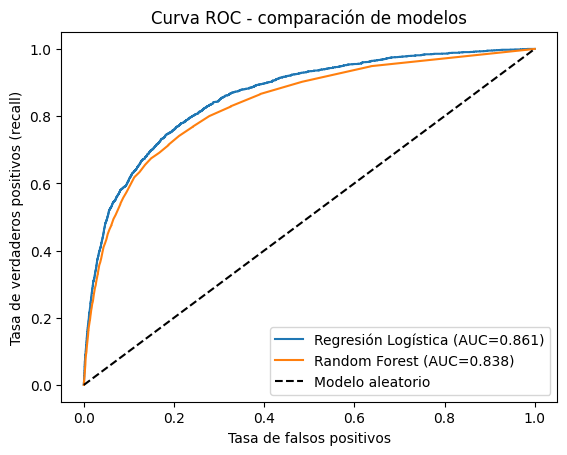

In [30]:
fpr_lr, tpr_lr, _ = roc_curve(y_test,y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_lr,tpr_lr, label=f'Regresión Logística (AUC={roc_auc_score(y_test,y_proba):.3f})')
plt.plot(fpr_rf,tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test,y_proba_rf):.3f})')
plt.plot([0,1],[0,1],'k--',label='Modelo aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curva ROC - comparación de modelos')
plt.legend()
plt.show() 

## Explicabilidad del modelo (SHAP)

Aunque la regresión ya es interpretable por sus coeficientes, usamos SHAP porque da explicaciones
por caso individual (no solo el efecto promedio de una variable), y es el estandar de la industria para explicabilidad - relevante en un contexto bancario regulado donde hay que poder justificar cada decisión

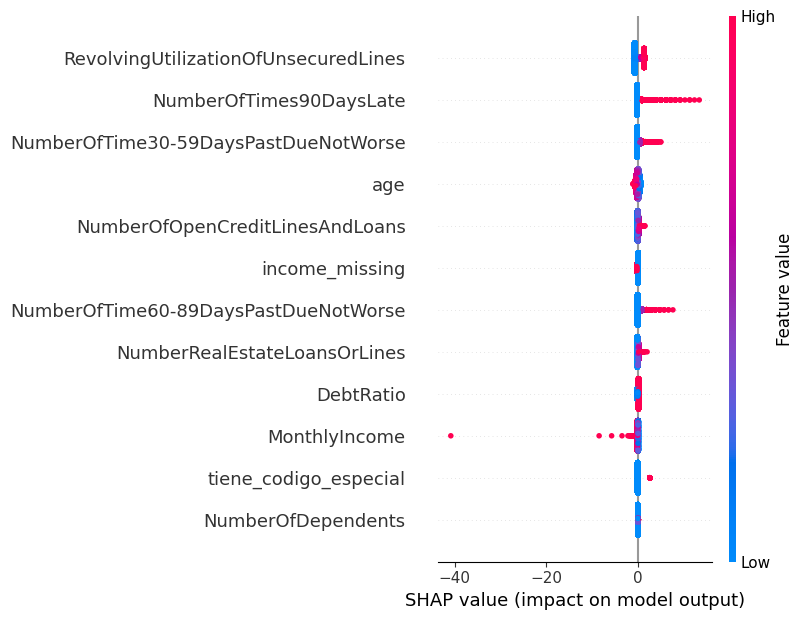

In [31]:
# LinearExplainer porque nuestro modelo es lineal (regresion logistica)
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Resumen general: qué variables influyen más, y en que dirección (rojo = sube el riesgo, azul = lo baja)
shap.summary_plot(shap_values, X_test_scaled,feature_names=X_train.columns.tolist())

### Interpretación de SHAP

El orden de importancia confirma los hallazgos del EDA: `RevolvingUtilizationOfUnsecuredLines` es la variable 
más influyente (consistente con su correlación de Spearman de 0.24), mientras que `DebtRatio` tiene un impacto 
mínimo (consistente con su falta de señal real tras la corrupción por ingreso faltante). Las variables de 
historial de atraso dominan el resto de la importancia, como es esperado en un modelo de riesgo crediticio. 
La bandera `income_missing` sí aporta señal; `tiene_codigo_especial` no.

### Explicación de un caso individual

Además de la vista general, SHAP permite explicar una predicción específica — útil para justificar ante un 
cliente o regulador por qué el modelo asignó tal riesgo a esa persona en particular.

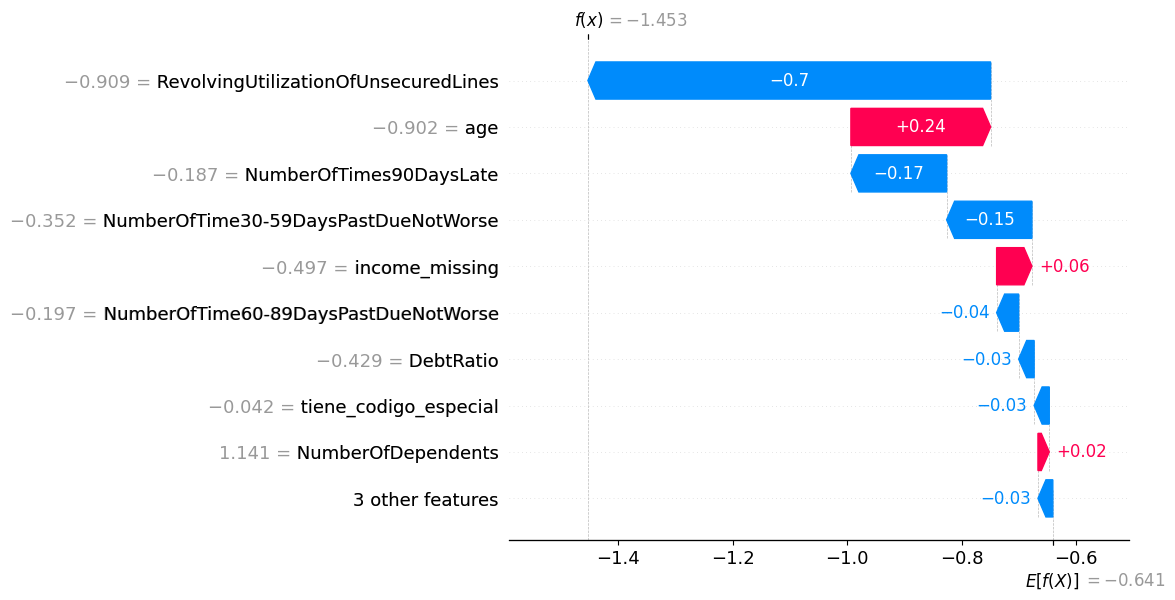

Probabilidad predicha de default: 0.18961092153275722
Valor real: 0


In [33]:
idx = 0  # elegimos el primer caso del test set para explicar

# Convertimos los arrays escalados de vuelta a DataFrame, conservando los nombres de columna
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Volvemos a crear el explainer con datos que ya tienen nombres de columna
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.plots.waterfall(shap_values[idx])
print("Probabilidad predicha de default:", y_proba[idx])
print("Valor real:", y_test.iloc[idx])

## Conclusiones

Este proyecto simula un caso real de scoring crediticio: predecir la probabilidad de que un solicitante caiga 
en incumplimiento de pago grave (90+ días de atraso) en los próximos 2 años, usando el dataset público 
"Give Me Some Credit" de Kaggle.

**Sobre los datos:** el EDA reveló varios problemas de calidad típicos de datasets financieros reales: un 
target desbalanceado (93.32% no default, 6.68% sí), ~20% de valores faltantes en `MonthlyIncome`, códigos 
centinela (96/98) en las columnas de días de atraso que no representaban conteos reales, y outliers extremos 
en `DebtRatio` y `RevolvingUtilizationOfUnsecuredLines`. Ningún problema se resolvió a ciegas: cada decisión 
de limpieza se tomó después de investigar la causa (por ejemplo, confirmar que el 92.7% de los valores 
extremos de `DebtRatio` coincidían con ingreso faltante, no eran errores aleatorios).

**Sobre el modelado:** comparé una regresión logística contra un Random Forest. Aunque Random Forest tuvo 
mayor accuracy (0.93 vs 0.81), su recall en la clase de default fue mucho más bajo (0.16 vs 0.75) — se le 
escapaba el 84% de los casos reales de default. Elegí la regresión logística como modelo final porque, para 
un banco, no detectar a alguien que sí va a caer en default es más costoso que negarle el crédito a alguien 
que sí hubiera pagado. También tuvo mejor AUC-ROC (0.861 vs 0.838).

**Sobre la explicabilidad:** con SHAP confirmé, usando el modelo ya entrenado, los mismos hallazgos del EDA: 
`RevolvingUtilizationOfUnsecuredLines` es la variable más importante (consistente con su correlación de 
Spearman de 0.24), mientras que `DebtRatio` casi no aporta señal (consistente con estar mayormente corrupta 
por el problema del ingreso faltante). Esto valida que las decisiones tomadas en el EDA no fueron arbitrarias.


**Limitaciones y siguientes pasos:** el modelo se entrenó con una sola partición train/test, sin validación 
cruzada, lo que puede hacer que el resultado varíe según la partición. Tampoco se ajustó el umbral de 
decisión (0.5 por default) ni se probaron modelos más avanzados como XGBoost o ajuste de hiperparámetros — 
sería el siguiente paso lógico para mejorar el recall sin sacrificar tanta precisión. `DebtRatio` sigue 
teniendo un problema de fondo sin resolver del todo (más allá del cap), y podría reconstruirse mejor si se 
tuviera acceso a los datos originales de ingreso.

**Lo que aprendí:** más allá del modelo en sí, este proyecto reforzó algo que aplica a cualquier problema de 
ciencia de datos: verificar con datos en vez de asumir (los códigos centinela, el problema de DebtRatio, el 
age heaping que resultó no ser real),a que la parte más importante es el preprocesamiento y limpieza de datos, y que el orden de las operaciones importa tanto como las operaciones 
mismas (train/test split antes de imputar, para evitar fuga de datos).